## Airline Tweet Sentiment Prediction

Given *tweets about airline experiences*, let's try to classify the **sentiment** of a given tweet (positive/negative/neutral).

We will use a TensorFlow ANN (with a GRU) to make our predictions.

Data source: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import re
import emoji
from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
data = pd.read_csv('archive/Tweets.csv')
data

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

### Preprocessing

In [7]:
confidence_threshold = 0.6

data = data.drop(data.query("airline_sentiment_confidence < @confidence_threshold").index, axis=0).reset_index(drop=True)

In [9]:
tweets_df = pd.concat([data['text'], data['airline_sentiment']], axis=1)

tweets_df

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica I didn't today... Must mean I n...,neutral
2,@VirginAmerica it's really aggressive to blast...,negative
3,@VirginAmerica and it's a really big bad thing...,negative
4,@VirginAmerica seriously would pay $30 a fligh...,negative
...,...,...
14397,@AmericanAir right on cue with the delays👌,negative
14398,@AmericanAir leaving over 20 minutes Late Flig...,negative
14399,@AmericanAir Please bring American Airlines to...,neutral
14400,"@AmericanAir you have my money, you change my ...",negative


In [11]:
tweets_df.isna().sum().sum()

np.int64(0)

In [12]:
tweets_df['airline_sentiment'].value_counts()

airline_sentiment
negative    9113
neutral     2997
positive    2292
Name: count, dtype: int64

In [13]:
sentiment_ordering = ['negative', 'neutral' , 'positive']

In [14]:
tweets_df['airline_sentiment'] = tweets_df['airline_sentiment'].apply(lambda x: sentiment_ordering.index(x))

In [19]:
tweets_df

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,1
1,@VirginAmerica I didn't today... Must mean I n...,1
2,@VirginAmerica it's really aggressive to blast...,0
3,@VirginAmerica and it's a really big bad thing...,0
4,@VirginAmerica seriously would pay $30 a fligh...,0
...,...,...
14397,@AmericanAir right on cue with the delays👌,0
14398,@AmericanAir leaving over 20 minutes Late Flig...,0
14399,@AmericanAir Please bring American Airlines to...,1
14400,"@AmericanAir you have my money, you change my ...",0


In [35]:
ps = PorterStemmer()

def process_tweet(tweet):
    new_tweet = tweet.lower()
    new_tweet = re.sub(r'@\w+', '', new_tweet) # Remove @s
    new_tweet = re.sub(r'#', '', new_tweet) # Remove hashtags
    new_tweet = re.sub(r':', ' ', emoji.demojize(new_tweet)) # turn emojis into words
    new_tweet = re.sub(r'http\$+', '', new_tweet) # Remove URLs
    new_tweet = re.sub(r'\$\$+', 'dollar', new_tweet) # Change dollar amounts to dollar
    new_tweet = re.sub(r'[^a-z0-9\s]', '', new_tweet) # Remove punctuation
    new_tweet = re.sub('r[0-9]+', 'number', new_tweet) # Change number values to number
    new_tweet = new_tweet.split(' ')
    new_tweet = list(map(lambda x: ps.stem(x), new_tweet)) # Stemming the words
    new_tweet = list(map(lambda x: x.strip(), new_tweet)) # Stripping whitespace from the words
    if '' in new_tweet:
        new_tweet.remove('')
    return new_tweet

In [36]:
tweets = tweets_df['text'].apply(process_tweet)

labels = np.array(tweets_df['airline_sentiment'])

In [37]:
tweets

0                                           [what, , said]
1        [i, didnt, today, must, mean, i, need, to, tak...
2        [it, realli, aggress, to, blast, obnoxi, enter...
3         [and, it, a, realli, big, bad, thing, about, it]
4        [serious, would, pay, 30, a, flight, for, seat...
                               ...                        
14397           [right, on, cue, with, the, delay, hand, ]
14398    [leav, over, 20, minut, late, flight, no, warn...
14399    [pleas, bring, american, airlin, to, blackberr...
14400    [you, have, my, money, you, chang, my, flight,...
14401    [we, have, 8, ppl, so, we, need, 2, know, how,...
Name: text, Length: 14402, dtype: object

In [38]:
# Get size of vocabulary
vocabulary = set()

for tweet in tweets:
    for word in tweet:
        if word not in vocabulary:
            vocabulary.add(word)

vocab_length = len(vocabulary)

# Get max length of a sequence
max_seq_length = 0

for tweet in tweets:
    if len(tweet) > max_seq_length:
        max_seq_length = len(tweet)

# Print results
print("Vocab Length:", vocab_length)
print("Max Sequence Length:", max_seq_length)

Vocab Length: 13045
Max Sequence Length: 90


In [39]:
tokenizer = Tokenizer(num_words = vocab_length)
tokenizer.fit_on_texts(tweets)

sequences = tokenizer.texts_to_sequences(tweets)

word_index = tokenizer.word_index

model_inputs = pad_sequences(sequences=sequences, maxlen=max_seq_length, padding='post')

In [40]:
sequences

[[48, 2, 222],
 [4, 193, 102, 757, 363, 4, 61, 1, 112, 152, 181],
 [14,
  139,
  3001,
  1,
  2082,
  3665,
  788,
  13,
  16,
  1780,
  1014,
  66,
  58,
  18,
  487,
  2280],
 [10, 14, 6, 139, 470, 217, 292, 85, 14],
 [428,
  78,
  205,
  235,
  6,
  5,
  8,
  83,
  19,
  193,
  18,
  28,
  5068,
  139,
  3,
  122,
  217,
  292,
  85,
  57,
  1576],
 [177, 1366, 311, 43, 4, 57, 1911, 28, 2559, 5069, 214, 67, 477, 2, 2],
 [139, 105, 6, 2560, 1429, 8, 3002, 332, 2281, 5070, 68, 31, 5071],
 [194, 4, 5072, 38, 4, 39, 2, 1430],
 [14, 22, 340, 10, 210, 41, 32, 358, 16, 179, 141, 1, 17],
 [124, 7, 109, 19, 2083, 12, 3, 518, 1307, 433, 15, 1308, 1505, 1912, 1913],
 [4, 1190, 659, 3666, 46, 180, 221, 166, 5073, 5074, 2, 1430],
 [28,
  12,
  540,
  6,
  120,
  364,
  225,
  229,
  85,
  11,
  617,
  181,
  1,
  2,
  66,
  4,
  341,
  128,
  936,
  9,
  11,
  348,
  181,
  257,
  1675],
 [2,
  51,
  57,
  16,
  1676,
  5075,
  995,
  111,
  125,
  112,
  70,
  3,
  1015,
  477,
  30,
  113,
  3

In [41]:
word_index

{'to': 1,
 '': 2,
 'the': 3,
 'i': 4,
 'flight': 5,
 'a': 6,
 'you': 7,
 'for': 8,
 'on': 9,
 'and': 10,
 'my': 11,
 'is': 12,
 'in': 13,
 'it': 14,
 'of': 15,
 'your': 16,
 'me': 17,
 'have': 18,
 'that': 19,
 'thank': 20,
 'get': 21,
 'wa': 22,
 'not': 23,
 'with': 24,
 'at': 25,
 'no': 26,
 'be': 27,
 'thi': 28,
 'but': 29,
 'from': 30,
 'http': 31,
 'hour': 32,
 'can': 33,
 'are': 34,
 'cancel': 35,
 'we': 36,
 'help': 37,
 'now': 38,
 'do': 39,
 'servic': 40,
 'an': 41,
 'delay': 42,
 'time': 43,
 'just': 44,
 'custom': 45,
 'so': 46,
 'been': 47,
 'what': 48,
 'will': 49,
 'call': 50,
 'im': 51,
 'bag': 52,
 'wait': 53,
 'up': 54,
 'plane': 55,
 'out': 56,
 'fli': 57,
 'they': 58,
 'our': 59,
 'hold': 60,
 'need': 61,
 '2': 62,
 'us': 63,
 'when': 64,
 'how': 65,
 'amp': 66,
 'go': 67,
 'there': 68,
 'if': 69,
 'all': 70,
 'whi': 71,
 'cant': 72,
 'tri': 73,
 'still': 74,
 'one': 75,
 'pleas': 76,
 'airlin': 77,
 'would': 78,
 'day': 79,
 'gate': 80,
 'flightl': 81,
 'back': 82,


In [42]:
model_inputs

array([[  48,    2,  222, ...,    0,    0,    0],
       [   4,  193,  102, ...,    0,    0,    0],
       [  14,  139, 3001, ...,    0,    0,    0],
       ...,
       [  76,  519,  444, ...,    0,    0,    0],
       [   7,   18,   11, ...,    0,    0,    0],
       [  36,   18,  339, ...,    0,    0,    0]],
      shape=(14402, 90), dtype=int32)

In [43]:
model_inputs.shape

(14402, 90)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(model_inputs, labels, train_size=0.7, random_state=22)

### Training

/home/aditya/miniconda3/envs/tfenv/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


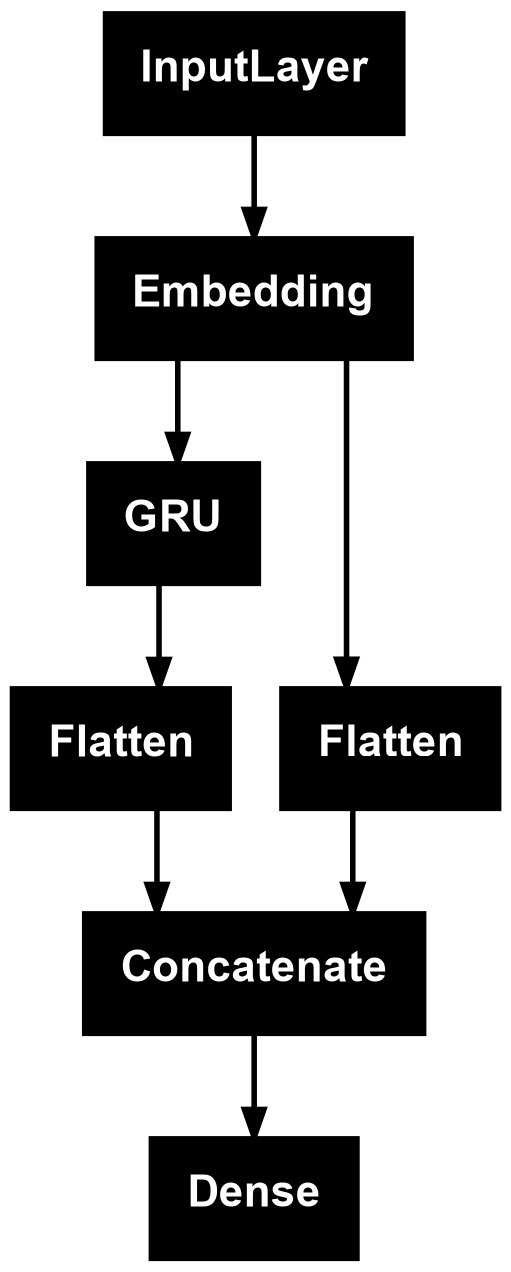

In [45]:
embedding_dim = 32

inputs = tf.keras.Input(shape=(max_seq_length, ))

embedding = tf.keras.layers.Embedding(
    input_dim=vocab_length,
    output_dim=embedding_dim,
    input_length=max_seq_length
)(inputs)

# Model A (just a Flatten layer)
flatten = tf.keras.layers.Flatten()(embedding)

# Model B (GRU with a Flatten layer)
gru = tf.keras.layers.GRU(units=embedding_dim)(embedding)
gru_flatten = tf.keras.layers.Flatten()(gru)

# Both A and B are fed into the output
concat = tf.keras.layers.concatenate([flatten, gru_flatten])

outputs = tf.keras.layers.Dense(3, activation='softmax')(concat)

model = tf.keras.Model(inputs, outputs)

tf.keras.utils.plot_model(model)

In [47]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

batch_size=32
epochs=100

history = model.fit(
    X_train, 
    y_train,
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau()
    ]
)

Epoch 1/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7932 - loss: 0.5251 - val_accuracy: 0.7838 - val_loss: 0.5524 - learning_rate: 0.0010
Epoch 2/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8642 - loss: 0.3841 - val_accuracy: 0.7957 - val_loss: 0.5192 - learning_rate: 0.0010
Epoch 3/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9059 - loss: 0.2852 - val_accuracy: 0.7928 - val_loss: 0.5155 - learning_rate: 0.0010
Epoch 4/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9354 - loss: 0.2106 - val_accuracy: 0.7908 - val_loss: 0.5312 - learning_rate: 0.0010
Epoch 5/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9562 - loss: 0.1563 - val_accuracy: 0.7938 - val_loss: 0.5426 - learning_rate: 0.0010
Epoch 6/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9727 - loss: 0.1153 - val_accuracy: 0.7928 - val_loss: 0.5633 - learning_rate: 0.0010


### Results

In [48]:
model.evaluate(X_test, y_test)

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8003 - loss: 0.4909


[0.49088355898857117, 0.8002777099609375]